In [194]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [195]:
df = pd.read_csv('12-health_risk_classification.csv')

In [196]:
df.head()

,bmi_score,blood_pressure_variation,activity_level_index,high_risk_flag
0,0.564223,0.652825,1.262925,1
1,-1.692569,2.981229,-0.180331,1
2,0.770383,0.400475,1.365806,1
3,2.135007,0.150832,3.084596,0
4,0.360342,1.026132,1.251574,1


In [197]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   bmi_score                 1000 non-null   float64
 1   blood_pressure_variation  1000 non-null   float64
 2   activity_level_index      1000 non-null   float64
 3   high_risk_flag            1000 non-null   int64  
dtypes: float64(3), int64(1)
memory usage: 31.4 KB


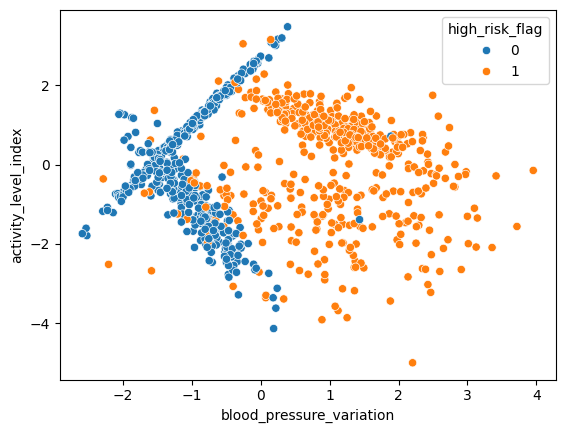

In [198]:
sns.scatterplot(x=df["blood_pressure_variation"], y=df["activity_level_index"], hue=df["high_risk_flag"])
plt.show()

In [199]:
df["high_risk_flag"].value_counts()

high_risk_flag
0    502
1    498
Name: count, dtype: int64

In [200]:
X = df.drop("high_risk_flag", axis=1)
y = df["high_risk_flag"]

In [201]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=15)

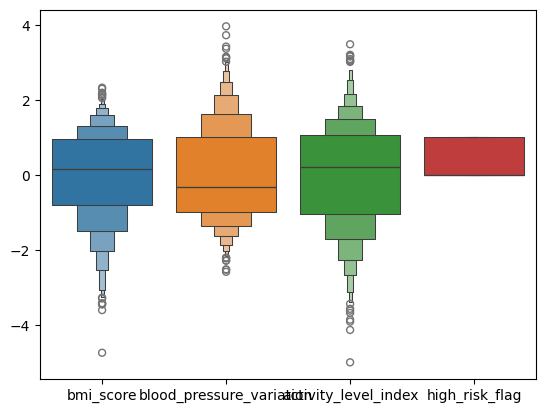

In [202]:
sns.boxenplot(df)
plt.show()

In [203]:
# Karar ağaçları hariç diğer bütün algoritmalarda scale işlemi yapmalıyız!
# Bu datada gerek olmasa da KNN algoritmasında da scaler gereklidir. Eğitim notebook olduğu için yapıyoruz.

In [204]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [205]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [206]:
from sklearn.neighbors import KNeighborsClassifier

In [207]:
classifier = KNeighborsClassifier(n_neighbors=5, algorithm='auto', weights="uniform")

In [208]:
classifier.fit(X_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [209]:
y_pred = classifier.predict(X_test)

In [210]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [211]:
print("confusion_matrix: \n", confusion_matrix(y_test,y_pred))
print("accuracy_score: ", accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

confusion_matrix: 
 [[124   2]
 [ 10 114]]
accuracy_score:  0.952
              precision    recall  f1-score   support

           0       0.93      0.98      0.95       126
           1       0.98      0.92      0.95       124

    accuracy                           0.95       250
   macro avg       0.95      0.95      0.95       250
weighted avg       0.95      0.95      0.95       250



In [212]:
classifier2 = KNeighborsClassifier(n_neighbors=5, algorithm="kd_tree", weights="uniform")

In [213]:
classifier2.fit(X_train,y_train)
y_pred2 = classifier2.predict(X_test)

print("confusion_matrix: \n", confusion_matrix(y_test,y_pred2))
print("accuracy_score: ", accuracy_score(y_test,y_pred2))
print(classification_report(y_test,y_pred2))

confusion_matrix: 
 [[124   2]
 [ 10 114]]
accuracy_score:  0.952
              precision    recall  f1-score   support

           0       0.93      0.98      0.95       126
           1       0.98      0.92      0.95       124

    accuracy                           0.95       250
   macro avg       0.95      0.95      0.95       250
weighted avg       0.95      0.95      0.95       250



In [214]:
classifier3 = KNeighborsClassifier(n_neighbors=3, algorithm="kd_tree", weights="uniform")

classifier3.fit(X_train,y_train)
y_pred3 = classifier3.predict(X_test)

print("confusion_matrix: \n", confusion_matrix(y_test,y_pred3))
print("accuracy_score: ", accuracy_score(y_test,y_pred3))
print(classification_report(y_test,y_pred3))

confusion_matrix: 
 [[125   1]
 [  9 115]]
accuracy_score:  0.96
              precision    recall  f1-score   support

           0       0.93      0.99      0.96       126
           1       0.99      0.93      0.96       124

    accuracy                           0.96       250
   macro avg       0.96      0.96      0.96       250
weighted avg       0.96      0.96      0.96       250



In [215]:
###################################################################################################################################################3

In [216]:
df_reg = pd.read_csv("12-house_energy_regression.csv") 

In [217]:
df_reg.head()

,avg_indoor_temp_change,outdoor_humidity_level,daily_energy_consumption_kwh
0,-0.167118,0.146714,-14.996950
1,-0.020902,0.117327,-12.678089
2,0.150419,0.364961,17.775455
3,0.555604,0.089581,6.661465
4,0.058209,-1.142970,-14.195530


In [218]:
df_reg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   avg_indoor_temp_change        1000 non-null   float64
 1   outdoor_humidity_level        1000 non-null   float64
 2   daily_energy_consumption_kwh  1000 non-null   float64
dtypes: float64(3)
memory usage: 23.6 KB


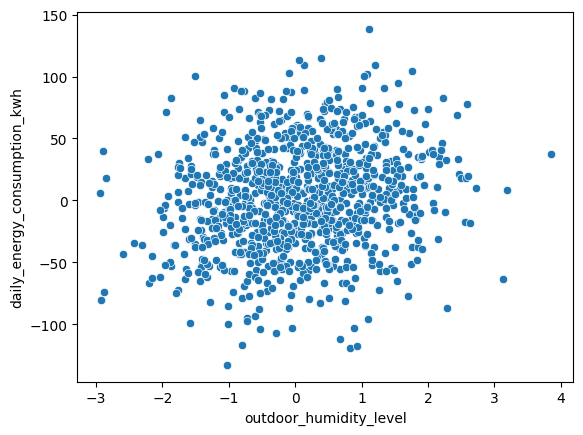

In [219]:
sns.scatterplot(x=df_reg['outdoor_humidity_level'], y=df_reg['daily_energy_consumption_kwh'])
plt.show()

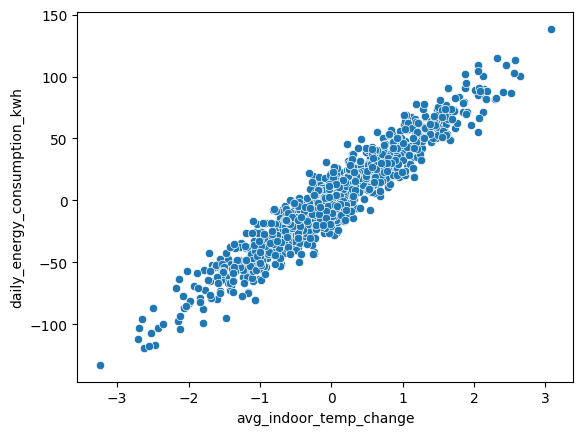

In [220]:
sns.scatterplot(x=df_reg['avg_indoor_temp_change'], y=df_reg['daily_energy_consumption_kwh'])
plt.show()

In [221]:
X2 = df_reg.drop("daily_energy_consumption_kwh", axis=1)
y2 = df_reg["daily_energy_consumption_kwh"]

In [222]:
X2_train,X2_test, y2_train,y2_test = train_test_split(X2,y2, test_size=0.3, random_state=15)

In [223]:
X2_train = scaler.fit_transform(X2_train)
X2_test = scaler.transform(X2_test)

In [224]:
from sklearn.neighbors import KNeighborsRegressor
regressor = KNeighborsRegressor(n_neighbors=5, algorithm="auto")

In [225]:
regressor.fit(X2_train,y2_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [226]:
y_pred_reg = regressor.predict(X2_test)

In [227]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [228]:
print("r2_score: ", r2_score(y2_test,y_pred_reg))
print("mse: ", mean_squared_error(y2_test,y_pred_reg))
print("mae: ", mean_absolute_error(y2_test,y_pred_reg))

r2_score:  0.9152685146562609
mse:  140.40201685069158
mae:  9.42143518926242


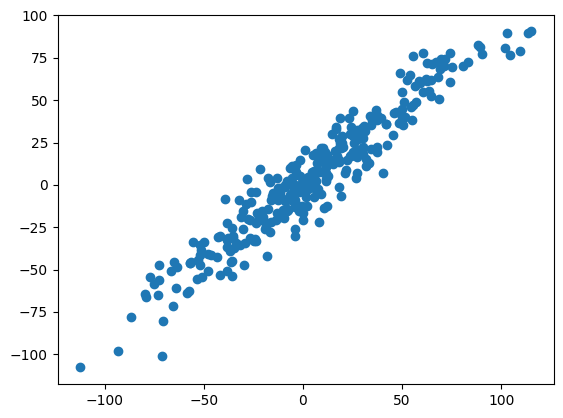

In [229]:
plt.scatter(y2_test, y_pred_reg)
plt.show()

In [230]:
regressor = KNeighborsRegressor(n_neighbors=7, algorithm="auto")
regressor.fit(X2_train,y2_train)
y_pred_reg = regressor.predict(X2_test)

print("r2_score: ", r2_score(y2_test,y_pred_reg))
print("mse: ", mean_squared_error(y2_test,y_pred_reg))
print("mae: ", mean_absolute_error(y2_test,y_pred_reg))

r2_score:  0.9164863388635838
mse:  138.3840541750219
mae:  9.331428506491209
